In [33]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
dir_path = '/Users/RachidAJ/Desktop/Statistics Projects'
data = pd.read_csv(f'{dir_path}/data.csv')

# Aisles Approach

In [34]:
transaction_df = data.groupby('order_id')['aisle'].apply(list).reset_index(name='aisle')
print(transaction_df.head())

transactions = transaction_df['aisle'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True, low_memory=True,verbose = 1)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7) 

   order_id                                              aisle
0         1  [yogurt, other creams cheeses, fresh vegetable...
1         2  [eggs, fresh vegetables, spices seasonings, oi...
2         3  [yogurt, soy lactosefree, packaged vegetables ...
3         4  [breakfast bakery, cold flu allergy, energy gr...
4         5  [fresh fruits, salad dressing toppings, prepar...

Example Transactions List (first 5):
[['yogurt', 'other creams cheeses', 'fresh vegetables', 'fresh vegetables', 'canned meat seafood', 'fresh fruits', 'fresh fruits', 'packaged cheese'], ['eggs', 'fresh vegetables', 'spices seasonings', 'oils vinegars', 'baking ingredients', 'fresh vegetables', 'doughs gelatins bake mixes', 'spreads', 'packaged vegetables fruits'], ['yogurt', 'soy lactosefree', 'packaged vegetables fruits', 'packaged vegetables fruits', 'soy lactosefree', 'fresh vegetables', 'poultry counter', 'bread'], ['breakfast bakery', 'cold flu allergy', 'energy granola bars', 'breakfast bars pastries', 'br

In [35]:
print("\nFrequent Itemsets:")
print(frequent_itemsets)

print("\nAssociation Rules:")
rules.head()


Frequent Itemsets:
      support                                           itemsets
0    0.076715                               (baking ingredients)
1    0.163958                                            (bread)
2    0.068667                                 (breakfast bakery)
3    0.074770                                           (butter)
4    0.069390                                  (candy chocolate)
..        ...                                                ...
151  0.051020         (milk, packaged vegetables fruits, yogurt)
152  0.050928  (packaged cheese, packaged vegetables fruits, ...
153  0.062319  (fresh fruits, milk, packaged vegetables fruit...
154  0.067929  (packaged cheese, fresh fruits, packaged veget...
155  0.076052  (fresh fruits, yogurt, packaged vegetables fru...

[156 rows x 2 columns]

Association Rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(canned jarred vegetables),(fresh vegetables),0.073715,0.444341,0.056155,0.761785,1.714413,1.0,0.023400,2.332590,0.449872,0.121573,0.571292,0.444081
1,(canned meals beans),(fresh vegetables),0.069799,0.444341,0.050033,0.716821,1.613222,1.0,0.019019,1.962218,0.408645,0.107805,0.490373,0.414711
2,(fresh dips tapenades),(fresh fruits),0.098128,0.556755,0.069495,0.708205,1.272023,1.0,0.014861,1.519030,0.237119,0.118716,0.341685,0.416513
3,(fresh herbs),(fresh fruits),0.093564,0.556755,0.070103,0.749254,1.345752,1.0,0.018011,1.767706,0.283441,0.120823,0.434295,0.437584
4,(fresh vegetables),(fresh fruits),0.444341,0.556755,0.318137,0.715974,1.285977,1.0,0.070748,1.560581,0.400212,0.465821,0.359213,0.643694


In [36]:
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=14, 
    width=1000,  
    height=900  
)

fig.show()


# Users Approach

In [37]:
sampled_users = data['user_id'].drop_duplicates().sample(n=10000,random_state=42)
data2 = data[data['user_id'].isin(sampled_users)]

In [38]:

transaction_df = data2.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)

   order_id                                       product_name
0        21  [Yuba Tofu Skin, Organic Firm Tofu, Frozen Org...
1        25  [Original Popcorn, Boomchickapop Sweet & Salty...
2        42  [Unsweetened Vanilla Almond Breeze, Pure Irish...
3        47  [Strawberries, Organic Blueberries, Raspberrie...
4        98  [Natural Spring Water, Organic Orange Juice Wi...

Example Transactions List (first 5):
[['Yuba Tofu Skin', 'Organic Firm Tofu', 'Frozen Organic Blueberries', 'Dairy-Free Cheddar Style Wedges', 'Cold Brew Coffee'], ['Original Popcorn', 'Boomchickapop Sweet & Salty Kettle Corn', 'Steamfresh Lightly Sauced Broccoli With Cheese Sauce', 'Delights Turkey Sausage Egg Whites & Cheese English Muffin', 'Ultra Thin Sliced Provolone Cheese', 'Cheese Shredded Mozzarella Reduced Fat 2%', 'All Whites 100% Egg Whites', 'Smok Cured Turkey Bacon', 'Shredded Hash Browns', 'Simply 9 White Meat Chicken & Whole Barley Recipe Dog Food', 'Craveables Four Cheese Pizza', 'Macaroni and Che

In [39]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5) 
rules1 = association_rules(frequent_itemsets, metric="lift", min_threshold=3)
print("\nFrequent Itemsets:")
print(frequent_itemsets)

print("\nAssociation Rules:")
rules1.head()


Frequent Itemsets:
       support                                           itemsets
0     0.001608                         (0% Fat Free Organic Milk)
1     0.003911                         (0% Greek Strained Yogurt)
2     0.001558                                          (1 Liter)
3     0.001029                               (1 Ply Paper Towels)
4     0.003080                                  (1% Low Fat Milk)
...        ...                                                ...
3958  0.001016  (Sparkling Water Grapefruit, Peach Pear Flavor...
3959  0.001004  (Sparkling Water Berry, Sparkling Water Grapef...
3960  0.001146  (Total 2% Lowfat Greek Strained Yogurt With Bl...
3961  0.001047  (Organic Baby Spinach, Organic Strawberries, O...
3962  0.001269  (Organic Strawberries, Organic Raspberries, Or...

[3963 rows x 2 columns]

Association Rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Organic Strawberries),(Aged White Cheddar Baked Rice & Corn Puffs Gl...,0.084115,0.003634,0.001047,0.012449,3.425514,1.0,0.000741,1.008926,0.773102,0.012077,0.008847,0.150292
1,(Aged White Cheddar Baked Rice & Corn Puffs Gl...,(Organic Strawberries),0.003634,0.084115,0.001047,0.288136,3.425514,1.0,0.000741,1.286601,0.710656,0.012077,0.222758,0.150292
2,(Organic Bartlett Pear),(Apple Honeycrisp Organic),0.011506,0.028469,0.001417,0.123126,4.324873,1.0,0.001089,1.107948,0.777728,0.036741,0.097431,0.086444
3,(Apple Honeycrisp Organic),(Organic Bartlett Pear),0.028469,0.011506,0.001417,0.049762,4.324873,1.0,0.001089,1.040259,0.791307,0.036741,0.038701,0.086444
4,(Organic Broccoli),(Apple Honeycrisp Organic),0.011001,0.028469,0.001127,0.102464,3.599084,1.0,0.000814,1.082442,0.730184,0.029398,0.076163,0.071028


In [40]:
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=14, 
    width=1000,  
    height=900  
)

fig.show()


# Products Approach

In [20]:
data.describe()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07
mean,1.710566e+06,2.557551e+04,8.367738e+00,5.900617e-01,1.029444e+05,1.713998e+01,2.737285e+00,1.343123e+01,1.060442e+01,7.121799e+01,9.918544e+00
std,9.874008e+05,1.409770e+04,7.139540e+00,4.918220e-01,5.946733e+04,1.749829e+01,2.093296e+00,4.246149e+00,9.156268e+00,3.819898e+01,6.281655e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,1.000000e+00,1.000000e+00
25%,8.554130e+05,1.351900e+04,3.000000e+00,0.000000e+00,5.143500e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00,3.100000e+01,4.000000e+00
50%,1.710660e+06,2.525600e+04,6.000000e+00,1.000000e+00,1.026260e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00,8.300000e+01,9.000000e+00
75%,2.565587e+06,3.793500e+04,1.100000e+01,1.000000e+00,1.544120e+05,2.400000e+01,5.000000e+00,1.600000e+01,1.500000e+01,1.070000e+02,1.600000e+01
max,3.421083e+06,4.968800e+04,1.450000e+02,1.000000e+00,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,1.340000e+02,2.100000e+01


On a 10000 users randomises sur 2.06E5 donc pas de signification ultime et si on rajoute plus de users ceci implique plus de complexite algorithmique

In [22]:
product_frequencies = data['product_name'].value_counts().reset_index()
product_frequencies.columns = ['product_name', 'frequency']

In [23]:
product_frequencies.describe()

,frequency
count,49685.000000
mean,680.670343
std,4987.769425
min,1.000000
25%,18.000000
50%,63.000000
75%,272.000000
max,491291.000000


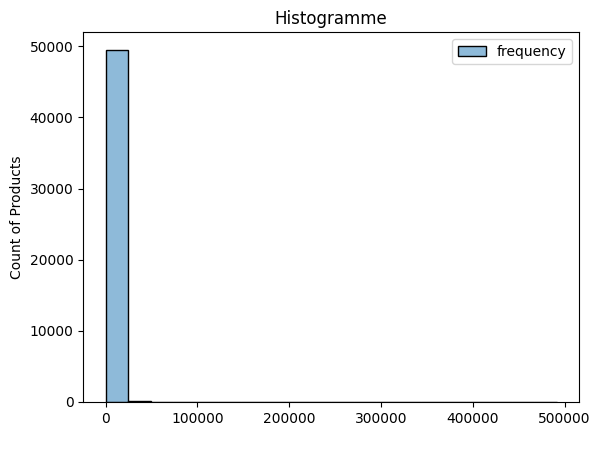

In [27]:
import seaborn as sns
sns.histplot(product_frequencies, color='b',bins=20)
plt.xlabel(" ")
plt.ylabel("Count of Products")
plt.title("Histogramme")
plt.show()

In [ ]:
significant_products = product_frequencies[product_frequencies['frequency'] >= 100000]

In [ ]:
significant_product_names = set(significant_products['product_name'])
filtered_data = data[data['product_name'].isin(significant_product_names)]
orders_with_significant_products = filtered_data['order_id'].unique()
n = int(orders_with_significant_products.shape[0] * 0.1)
indices = np.random.default_rng(seed=42).choice(orders_with_significant_products.shape[0], n, replace=False)
sampled_array = orders_with_significant_products[indices]
final_data = data[data['order_id'].isin(sampled_array)]

In [ ]:
final_data.describe()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,2.219496e+06,2.219496e+06,2.219496e+06,2.219496e+06,2.219496e+06,2.219496e+06,2.219496e+06,2.219496e+06,2.219496e+06,2.219496e+06,2.219496e+06
mean,1.711077e+06,2.581046e+04,9.452337e+00,6.145823e-01,1.030730e+05,1.778149e+01,2.692000e+00,1.342047e+01,1.055506e+01,7.034889e+01,9.464996e+00
std,9.869651e+05,1.395206e+04,7.609621e+00,4.866939e-01,5.945638e+04,1.779618e+01,2.124166e+00,4.264904e+00,8.956858e+00,3.859048e+01,6.255155e+00
min,3.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,1.000000e+00,1.000000e+00
25%,8.563690e+05,1.398400e+04,4.000000e+00,0.000000e+00,5.141600e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00,2.400000e+01,4.000000e+00
50%,1.711176e+06,2.514600e+04,8.000000e+00,1.000000e+00,1.027650e+05,1.200000e+01,2.000000e+00,1.300000e+01,7.000000e+00,8.300000e+01,7.000000e+00
75%,2.564043e+06,3.815900e+04,1.300000e+01,1.000000e+00,1.549160e+05,2.500000e+01,5.000000e+00,1.600000e+01,1.400000e+01,1.060000e+02,1.600000e+01
max,3.421062e+06,4.968800e+04,1.450000e+02,1.000000e+00,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,1.340000e+02,2.100000e+01


In [ ]:

transaction_df = final_data.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)

   order_id                                       product_name
0         3  [Total 2% with Strawberry Lowfat Greek Straine...
1        23  [Organic Baby Spinach Salad, Red Leaf Lettuce,...
2        55  [Unsalted Butter, Semi-Sweet Chocolate Premium...
3        85  [Strawberries, Green Seedless Grapes, Red Glob...
4        96  [Roasted Turkey, Organic Cucumber, Organic Gra...

Example Transactions List (first 5):
[['Total 2% with Strawberry Lowfat Greek Strained Yogurt', 'Unsweetened Almondmilk', 'Lemons', 'Organic Baby Spinach', 'Unsweetened Chocolate Almond Breeze Almond Milk', 'Organic Ginger Root', 'Air Chilled Organic Boneless Skinless Chicken Breasts', 'Organic Ezekiel 49 Bread Cinnamon Raisin'], ['Organic Baby Spinach Salad', 'Red Leaf Lettuce', 'Potato Yukon Gold Organic', 'White Corn', 'Organic Avocado', 'Gluten-Free Supergrain Pasta Organic Corn & Quinoa Blend Penne', 'Gluten and Dairy Free Sonoma Veggie Burger', 'Organic Three Grain Tempeh', 'Lime', 'Organic Red Onion', 'Dair

In [ ]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5) 
print("\nFrequent Itemsets:")
print(frequent_itemsets)

print("\nAssociation Rules:")
rules.head()


Frequent Itemsets:
       support                                           itemsets
0     0.001476                         (0% Fat Free Organic Milk)
1     0.002389                         (0% Greek Strained Yogurt)
2     0.001323                                          (1 Liter)
3     0.002348                                  (1% Low Fat Milk)
4     0.005961                                   (1% Lowfat Milk)
...        ...                                                ...
8466  0.001499  (Organic Baby Spinach, Banana, Large Lemon, Or...
8467  0.001195  (Limes, Organic Baby Spinach, Banana, Organic ...
8468  0.001241  (Organic Baby Spinach, Banana, Organic Strawbe...
8469  0.001066  (Limes, Organic Baby Spinach, Large Lemon, Org...
8470  0.001031  (Organic Baby Spinach, Organic Raspberries, Or...

[8471 rows x 2 columns]

Association Rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(0% Greek Strained Yogurt),(Bag of Organic Bananas),0.002389,0.231630,0.001435,0.600490,2.592455,1.0,0.000881,1.923282,0.615736,0.006168,0.480055,0.303342
1,(1% Low Fat Milk),(Banana),0.002348,0.287327,0.001563,0.665835,2.317343,1.0,0.000889,2.132700,0.569809,0.005426,0.531111,0.335638
2,(2% Reduced Fat Milk),(Banana),0.009580,0.287327,0.005539,0.578240,2.012479,1.0,0.002787,1.689758,0.507966,0.019011,0.408199,0.298759
3,(Almond Milk Blueberry Yogurt),(Almond Milk Strawberry Yogurt),0.001979,0.002295,0.001048,0.529586,230.722429,1.0,0.001044,2.120907,0.997640,0.324864,0.528504,0.493109
4,(Apples),(Bag of Organic Bananas),0.002916,0.231630,0.001780,0.610442,2.635418,1.0,0.001105,1.972414,0.622368,0.007647,0.493007,0.309063


In [ ]:
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=1000,  
    height=900
)

fig.show()


# Departments Approach

In [ ]:
orders = data['order_id'].unique()
n = int(orders.shape[0] * 0.1)
indices = np.random.default_rng(seed=42).choice(orders.shape[0], n, replace=False)
sampled_array = orders[indices]
final_data = data[data['order_id'].isin(sampled_array)]
departments=final_data['department'].unique()
data=final_data

In [ ]:
departments

array(['snacks', 'pantry', 'frozen', 'missing', 'beverages',
       'meat seafood', 'dry goods pasta', 'dairy eggs', 'canned goods',
       'household', 'international', 'bakery', 'breakfast',
       'personal care', 'deli', 'alcohol', 'babies', 'other', 'pets',
       'bulk'], dtype=object)

In [ ]:
dairy_eggs=data[data['department']=='dairy eggs']
produce=data[data['department']=='produce']
canned_goods=data[data['department']=='canned goods']
beverages=data[data['department']=='beverages']
deli=data[data['department']=='deli']
snacks=data[data['department']=='snacks']
pantry=data[data['department']=='pantry']
frozen=data[data['department']=='frozen']
meat_seafood=data[data['department']=='meat seafood']
household=data[data['department']=='household']
bakery=data[data['department']=='bakery']
personal_care=data[data['department']=='personal care']
dry_goods_pasta=data[data['department']=='dry goods pasta']
babies=data[data['department']=='babies']
missing=data[data['department']=='missing']
other=data[data['department']=='other']
breakfast=data[data['department']=='breakfast']
international=data[data['department']=='international']
alcohol=data[data['department']=='alcohol']
bulk=data[data['department']=='bulk']
pets=data[data['department']=='pets']

In [ ]:

transaction_df = dairy_eggs.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)

   order_id                                       product_name
0        13  [Philadelphia Original Cream Cheese, Hampshire...
1        26  [Organic Unsweetened Almond Milk, Organic Egg ...
2        61  [Dairy Free Unsweetened Coconut Milk, Original...
3        72  [Toasted Coconut Almondmilk Blend, Vegan Butte...
4        79                                       [Whole Milk]

Example Transactions List (first 5):
[['Philadelphia Original Cream Cheese', 'Hampshire 100% Natural Sour Cream'], ['Organic Unsweetened Almond Milk', 'Organic Egg Whites'], ['Dairy Free Unsweetened Coconut Milk', 'Original Almondmilk', 'Organic Low Fat Milk', 'Half And Half Cream', 'Non Fat Greek Yogurt', '0% Greek Strained Yogurt'], ['Toasted Coconut Almondmilk Blend', 'Vegan Buttery Sticks', 'Organic  Unsalted  Butter', 'Organic Homogenized Whole Milk'], ['Whole Milk']]
Processing 36 combinations | Sampling itemset size 32


In [ ]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5) 
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=1000,  
    height=900
)

fig.show()


In [ ]:
transaction_df = beverages.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5) 
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=1000,  
    height=900
)

fig.show()


   order_id                                       product_name
0         4  [Original Orange Juice, Sugarfree Energy Drink...
1         5            [Natural Artesian Water, Mini & Mobile]
2         6                                          [Cleanse]
3         7                                     [Orange Juice]
4         9       [Distilled Water, 100% Apple Juice Original]

Example Transactions List (first 5):
[['Original Orange Juice', 'Sugarfree Energy Drink', 'Energy Drink'], ['Natural Artesian Water, Mini & Mobile'], ['Cleanse'], ['Orange Juice'], ['Distilled Water', '100% Apple Juice Original']]
Processing 48 combinations | Sampling itemset size 32


In [ ]:
transaction_df = personal_care.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2) 
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=1000,  
    height=900
)

fig.show()


   order_id                                       product_name
0         4                          [Honey/Lemon Cough Drops]
1        15  [Honeysuckle Hand Soap, Olive Oil & Aloe Vera ...
2        23  [Fluoride-Free Antiplaque & Whitening Spearmin...
3        71                [Clay Instant Luminous Facial Mask]
4        98                  [Olive Oil & Aloe Vera Hand Soap]

Example Transactions List (first 5):
[['Honey/Lemon Cough Drops'], ['Honeysuckle Hand Soap', 'Olive Oil & Aloe Vera Hand Soap'], ['Fluoride-Free Antiplaque & Whitening Spearmint Toothpaste'], ['Clay Instant Luminous Facial Mask'], ['Olive Oil & Aloe Vera Hand Soap']]
Processing 9 combinations | Sampling itemset size 2


In [ ]:
transaction_df = babies.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7) 
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=(1000),  
    height=900
)

fig.show()


   order_id                                       product_name
0       289  [First Prunes, Spinach Peas & Pear Stage 2 Bab...
1       306                 [Sunny Days Strawberry Snack Bars]
2       573        [Apples, Kale & Avocados Organic Baby Food]
3       602            [Gluten Free SpongeBob Spinach Littles]
4      1023             [Organic Go Go Apple Peach Applesauce]

Example Transactions List (first 5):
[['First Prunes', 'Spinach Peas & Pear Stage 2 Baby Food'], ['Sunny Days Strawberry Snack Bars'], ['Apples, Kale & Avocados Organic Baby Food'], ['Gluten Free SpongeBob Spinach Littles'], ['Organic Go Go Apple Peach Applesauce']]
Processing 115 combinations | Sampling itemset size 42


In [ ]:
dir_path = '/Users/RachidAJ/Desktop/Statistics Projects'
data = pd.read_csv(f'{dir_path}/data.csv')
orders = data['order_id'].unique()
n = int(orders.shape[0] * 0.5)
indices = np.random.default_rng(seed=42).choice(orders.shape[0], n, replace=False)
sampled_array = orders[indices]
final_data = data[data['order_id'].isin(sampled_array)]
departments=final_data['department'].unique()
data=final_data

In [ ]:
dairy_eggs=data[data['department']=='dairy eggs']
produce=data[data['department']=='produce']
canned_goods=data[data['department']=='canned goods']
beverages=data[data['department']=='beverages']
deli=data[data['department']=='deli']
snacks=data[data['department']=='snacks']
pantry=data[data['department']=='pantry']
frozen=data[data['department']=='frozen']
meat_seafood=data[data['department']=='meat seafood']
household=data[data['department']=='household']
bakery=data[data['department']=='bakery']
personal_care=data[data['department']=='personal care']
dry_goods_pasta=data[data['department']=='dry goods pasta']
babies=data[data['department']=='babies']
missing=data[data['department']=='missing']
other=data[data['department']=='other']
breakfast=data[data['department']=='breakfast']
international=data[data['department']=='international']
alcohol=data[data['department']=='alcohol']
bulk=data[data['department']=='bulk']
pets=data[data['department']=='pets']

In [ ]:
transaction_df = household.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2) 
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=(1000),  
    height=900
)

fig.show()


   order_id                                     product_name
0        22                                  [Sandwich Bags]
1        27                                [Parchment Paper]
2        51                                  [Cookie Sheets]
3        79  [Sponge Scrubber - 3 CT, Original Magic Eraser]
4        93  [Ultra Apple Blossom Antibacterial Dish Liquid]

Example Transactions List (first 5):
[['Sandwich Bags'], ['Parchment Paper'], ['Cookie Sheets'], ['Sponge Scrubber - 3 CT', 'Original Magic Eraser'], ['Ultra Apple Blossom Antibacterial Dish Liquid']]
Processing 12 combinations | Sampling itemset size 2


In [ ]:
transaction_df = snacks.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2) 
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=(1000),  
    height=900
)

fig.show()


   order_id                                       product_name
0         4  [Chewy 25% Low Sugar Chocolate Chip Granola, T...
1        12  [Sweet & Salty Snack Mix, Game Day Barbecue Tr...
2        13                            [Original Potato Chips]
3        16  [Original Popcorn, Sea Salt Made With Organic ...
4        23                     [34% Cacao Milk Chocolate Bar]

Example Transactions List (first 5):
[['Chewy 25% Low Sugar Chocolate Chip Granola', 'Tiny Twists Pretzels', 'Traditional Snack Mix', 'Goldfish Cheddar Baked Snack Crackers'], ['Sweet & Salty Snack Mix', 'Game Day Barbecue Trail Mix', 'Chocolate Caramel Cashew Trail Mix'], ['Original Potato Chips'], ['Original Popcorn', 'Sea Salt Made With Organic Grain Rice Chips'], ['34% Cacao Milk Chocolate Bar']]
Processing 18 combinations | Sampling itemset size 2


In [ ]:
transaction_df = canned_goods.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2) 
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=(1000),  
    height=900
)

fig.show()


   order_id                                       product_name
0         1             [Lightly Smoked Sardines in Olive Oil]
1        10                              [Organic Black Beans]
2        12                    [Cheddar Cheese Condensed Soup]
3        15                        [Pinto Beans No Salt Added]
4        27  [Organic Low Sodium Vegetable Broth, Organic N...

Example Transactions List (first 5):
[['Lightly Smoked Sardines in Olive Oil'], ['Organic Black Beans'], ['Cheddar Cheese Condensed Soup'], ['Pinto Beans No Salt Added'], ['Organic Low Sodium Vegetable Broth', 'Organic No Salt Added Diced Tomatoes', 'No Salt Added Black Beans']]
Processing 111 combinations | Sampling itemset size 2


In [ ]:
transaction_df = frozen.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2) 
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=(1000),  
    height=900
)

fig.show()

   order_id                                       product_name
0         7                                 [Pineapple Chunks]
1        12  [All Natural Boneless Skinless Chicken Breasts...
2        14  [Organic Mini Homestyle Waffles, Naturals Chic...
3        23       [Gluten and Dairy Free Sonoma Veggie Burger]
4        25  [Steamfresh Lightly Sauced Broccoli With Chees...

Example Transactions List (first 5):
[['Pineapple Chunks'], ['All Natural Boneless Skinless Chicken Breasts', 'Combination Pizza Rolls'], ['Organic Mini Homestyle Waffles', 'Naturals Chicken Nuggets', 'Corn Meal Pizza Crust', 'Organic Broccoli Florets'], ['Gluten and Dairy Free Sonoma Veggie Burger'], ['Steamfresh Lightly Sauced Broccoli With Cheese Sauce', 'Delights Turkey Sausage Egg Whites & Cheese English Muffin', 'Shredded Hash Browns', 'Craveables Four Cheese Pizza', 'Macaroni and Cheese']]
Processing 69 combinations | Sampling itemset size 2


In [ ]:
transaction_df = international.groupby('order_id')['product_name'].apply(list).reset_index(name='product_name')
print(transaction_df.head())

transactions = transaction_df['product_name'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.001, use_colnames=True, low_memory=True,verbose = 1)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2) 
import plotly.graph_objects as go

rules["antecedents"] = rules["antecedents"].astype(str)
rules["consequents"] = rules["consequents"].astype(str)

labels = list(pd.concat([rules["antecedents"], rules["consequents"]]).unique())
label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[a] for a in rules["antecedents"]]
targets = [label_index[c] for c in rules["consequents"]]
values = rules["support"].tolist()

fig = go.Figure(go.Sankey(
    node=dict(
        pad=80,  
        thickness=50,  
        line=dict(color="black", width=1), 
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(
    title_text="Diagramme de Sankey des règles d'association",
    font_size=10, 
    width=(1000),  
    height=900
)

fig.show()

   order_id                                      product_name
0        14                            [Sriracha Chili Sauce]
1        91                     [Lightly Breaded Fish Sticks]
2        93  [Crunchy Taco Shells, 37% Less Sodium Soy Sauce]
3       134                   [Roasted Sesame Seaweed Snacks]
4       147     [Sweet Red Chili Dipping & All-Purpose Sauce]

Example Transactions List (first 5):
[['Sriracha Chili Sauce'], ['Lightly Breaded Fish Sticks'], ['Crunchy Taco Shells', '37% Less Sodium Soy Sauce'], ['Roasted Sesame Seaweed Snacks'], ['Sweet Red Chili Dipping & All-Purpose Sauce']]
Processing 24 combinations | Sampling itemset size 2
